# Social Personas

Does giving Player 2 a social persona change how it negotiates? Following Bianchi et al.
(NegotiationArena, §2), Player 1 keeps the default behaviour while Player 2 is assigned one of
three personas: **default** (none), **desperate** (feign desperation and beg), or **cunning**
(manipulate the opponent and insult them). Every game is **self-play** — both seats are the same
model — so any edge P2 gains is the persona plus the seat, not a capability gap. The `default`
condition already carries P1's structural seat advantage, so the effect of a persona is read as
the change *from* `default`, not as a raw P2-vs-P1 score.

Per game and tier: 3 model families $\times$ 3 personas $\times$ 30 games = 90 runs per persona,
270 per cell. Three tiers (4–9B / 12–14B / 24–27B) and two parse-retry conditions
(`no_retries`, `retry3`).

### Metrics

| Metric | Why it is reported |
|---|---|
| **Completion rate** | Prerequisite, and a direct test of whether the hostile/begging text itself breaks the protocol. Separates *format* failure (repaired by `retry3`) from *negotiation* breakdown. |
| **P2 win rate** (ties excluded, Wilson 95% CI) | The headline: does the persona let P2 beat its identical default opponent more often? Read as the gap above the `default` bar. |
| **P2 average payoff** (native units, bootstrap 95% CI) | What P2 actually keeps. Diverges from win rate when a persona wins decided games but collapses others to 0. |
| **No-deal rate** (Wilson 95% CI) | The mechanism: tests whether a persona destroys value (a rejected game scores 0 for both). |

### Bianchi et al. reference points
- **Trading:** both personas raised P2's win rate and payoff.
- **BuySell:** the buyer (P2) already wins (price settles below the midpoint); personas slightly raised payoff.
- **Ultimatum:** personas had a large effect — without one the responder rarely beat the proposer;
  cunning raised P2's win rate to 82% but barely improved payoff, because the hostility broke deals
  (the "risk of cunning").

In [27]:
import sys, os, json, warnings
from pathlib import Path
import matplotlib.patches as mpatches


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)

    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass

    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root containing .logs, configs, and _notebooks")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

# Publication design system (_notebooks/oss/style): serif 8-9 pt, faint grid,
# constrained layout -- never call tight_layout in figure code.
import style
style.apply_thesis_style()
COLORBLIND_PALETTE = sns.color_palette("colorblind", n_colors=4).as_hex()
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.cycler(color=COLORBLIND_PALETTE)
matplotlib.rcParams["axes.edgecolor"] = "#8A8880"
matplotlib.rcParams["axes.labelcolor"] = "#3D3C38"
matplotlib.rcParams["xtick.color"] = "#3D3C38"
matplotlib.rcParams["ytick.color"] = "#3D3C38"
matplotlib.rcParams["grid.color"] = "#EAEDF0"
matplotlib.rcParams["grid.alpha"] = 0.9
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Open Sans", "Noto Sans", "Liberation Sans", "DejaVu Sans"]
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["axes.titlesize"] = 11
matplotlib.rcParams["axes.titleweight"] = "normal"
matplotlib.rcParams["axes.titlecolor"] = "#3D3C38"
matplotlib.rcParams["axes.titlepad"] = 10
matplotlib.rcParams["figure.titlesize"] = 11
matplotlib.rcParams["axes.linewidth"] = 0.8
matplotlib.rcParams["axes.grid.axis"] = "y"
matplotlib.rcParams["legend.frameon"] = False
matplotlib.rcParams["axes.unicode_minus"] = False   # the sans-serif stack lacks U+2212; use ASCII hyphen
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

LOGS_ROOT = str(ROOT_DIR / ".logs")
SIZES = ["very_small", "small", "medium"]
NOTEBOOK_NAME = "2_persona_analysis"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save figures WITHOUT the descriptive title -- the LaTeX \caption supplies it.
    Panel/facet titles (game, tier) are kept; only the whole-figure title is hidden.
    """
    hidden = []
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    real_axes = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    if len(real_axes) == 1 and real_axes[0].get_title():
        t = real_axes[0].title
        t.set_visible(False); hidden.append(t)
    path = FIG_DIR / f"{slug}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    for artist in hidden:
        artist.set_visible(True)
    return path

In [28]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name

def resource_value(res):
    return sum(res["_value"].values())

def model_family(name):
    low = name.lower()
    if low.startswith("gemma"): return "Gemma"
    if low.startswith(("ministral", "mistral")): return "Mistral"
    if low.startswith("qwen"): return "Qwen"
    return "Other"

In [29]:
import re
from scipy import stats as sps
from style import wilson_ci, bootstrap_ci, errbars_from_ci

GAMES = {"Trading": "trading", "Ultimatum": "ultimatum", "BuySell": "buysell"}
CONDITIONS = ["retry3", "no_retries"]
FAMILIES = ["Gemma", "Mistral", "Qwen"]
PERSONAS = ["default", "desperate", "cunning"]
PERSONA_LABEL = {"default": "Default", "desperate": "Desperate", "cunning": "Cunning"}
SIZE_LABELS = style.SIZE_LABEL

persona_pal = style.PERSONA_COLORS                                  # default/desperate/cunning
fam_pal = {f: style.FAMILY_COLORS[f.lower()] for f in FAMILIES}
cond_pal = {"no_retries": "#9AA0A6", "retry3": "#0173B2"}
PHASE_TEXT = "#3D3C38"
# feasible payoff ranges (as in the cross-play benchmark); BuySell surplus with price in [0,100]
PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}
# even-outcome reference per game: zero-sum parity / even split / equal 10-ZUP surplus split
NEUTRAL = {"Trading": 0, "Ultimatum": 50, "BuySell": 10}
PAYOFF_AXIS = {"Trading": "Net resources", "Ultimatum": "Dollars kept", "BuySell": "Surplus (ZUP)"}
_PERSONA_RE = re.compile(r"_(default|desperate|cunning)(?:/|$)")


def _persona_from_path(path):
    m = _PERSONA_RE.search(path)
    return m.group(1) if m else None


def _load_run(path, game):
    with open(path) as f:
        data = json.load(f)
    states = data["game_state"]
    last = states[-1]
    players = data["players"]
    # Completed only if it reached END *and* wrote a summary: a few BuySell runs
    # reach END with no summary block, i.e. no valid terminal state was recorded.
    completed = last.get("current_iteration") == "END" and "summary" in last
    turn_states = [s for s in states if s.get("current_iteration") not in ("START", "END")]
    settings = states[0].get("settings", {})
    behaviours = settings.get("player_social_behaviour", ["", ""])
    persona = _persona_from_path(path)
    if persona is None:                                             # fall back to the prompt text
        b2 = behaviours[1] if len(behaviours) > 1 else ""
        persona = "default" if not b2 else ("cunning" if "cunning" in b2 else "desperate")
    row = dict(
        model=clean_name(players[0].get("model_id", players[0].get("model", "?"))),
        persona=persona, completed=completed, num_turns=len(turn_states),
        payoff_1=np.nan, payoff_2=np.nan, deal=False, final_response=None, path=path,
    )
    if not completed:
        return row
    s = last["summary"]
    row["final_response"] = str(s.get("final_response"))
    row["deal"] = row["final_response"] == "ACCEPT"
    if game == "Trading":
        init, fin = s["initial_resources"], s["final_resources"]
        p1 = resource_value(fin[0]) - resource_value(init[0])
        p2 = resource_value(fin[1]) - resource_value(init[1])
    elif game == "Ultimatum":
        p1 = resource_value(s["player_outcome"][0])
        p2 = resource_value(s["player_outcome"][1])
    else:  # BuySell: P1 = seller (cost 40), P2 = buyer (value 60); player_outcome = surplus
        o1, o2 = s["player_outcome"]
        try:
            p1, p2 = float(o1), float(o2)
        except (TypeError, ValueError):
            p1 = p2 = np.nan
    if not row["deal"]:                                             # no deal -> both score 0
        p1 = p2 = 0.0
    row["payoff_1"], row["payoff_2"] = p1, p2
    return row


_rows = []
for _game, _prefix in GAMES.items():
    for _cond in CONDITIONS:
        _suffix = "_retry3" if _cond == "retry3" else ""
        for _size in SIZES:
            _dir = os.path.join(LOGS_ROOT, f"section_two/{_prefix}_section_two_personas{_suffix}/{_size}")
            for _root, _dirs, _files in os.walk(_dir):
                if "game_state.json" not in _files:
                    continue
                try:
                    r = _load_run(os.path.join(_root, "game_state.json"), _game)
                except Exception:
                    continue
                r.update(game=_game, condition=_cond, size=_size)
                _rows.append(r)

MASTER = pd.DataFrame(_rows)
MASTER["family"] = MASTER["model"].map(model_family)
MASTER["persona"] = pd.Categorical(MASTER["persona"], PERSONAS, ordered=True)
_lo = MASTER["game"].map(lambda g: PAYOFF_BOUNDS[g][0])
_hi = MASTER["game"].map(lambda g: PAYOFF_BOUNDS[g][1])
MASTER["payoff_valid"] = MASTER["payoff_1"].between(_lo, _hi) & MASTER["payoff_2"].between(_lo, _hi)
MASTER["no_deal"] = MASTER["completed"] & ~MASTER["deal"]


def _winner(r):
    if not r.completed:
        return "incomplete"
    if not r.payoff_valid or not np.isfinite(r.payoff_1):
        return "invalid"
    if r.payoff_1 > r.payoff_2: return "P1"
    if r.payoff_2 > r.payoff_1: return "P2"
    return "tie"


MASTER["winner"] = MASTER.apply(_winner, axis=1)
# P2 carries the persona. win_2 = 1 if P2 wins, 0 if P1 wins, NaN for ties/no-deals (excluded).
MASTER["win_2"] = np.where(MASTER["winner"].isin(["P1", "P2"]),
                           (MASTER["winner"] == "P2").astype(float), np.nan)

RETRY3 = MASTER[MASTER["condition"] == "retry3"].copy()
NORETRY = MASTER[MASTER["condition"] == "no_retries"].copy()


def winrate(df, by):
    """Ties-excluded P2 win rate per group, with Wilson 95% CIs."""
    d = df[df["win_2"].notna()]
    t = d.groupby(by, observed=True)["win_2"].agg(k="sum", n="count").reset_index()
    t["rate"] = t["k"] / t["n"]
    t[["lo", "hi"]] = t.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)
    return t


def rate_table(df, col, by):
    """Generic proportion (e.g. completed, no_deal) per group, with Wilson 95% CIs."""
    t = df.groupby(by, observed=True)[col].agg(k="sum", n="count").reset_index()
    t["rate"] = t["k"] / t["n"]
    t[["lo", "hi"]] = t.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)
    return t


def payoff(df, by, col="payoff_2"):
    """Mean P2 payoff per group over payoff-valid completed games, bootstrap 95% CIs."""
    keys = by if isinstance(by, list) else [by]
    pv = df[df["completed"] & df["payoff_valid"]]
    out = []
    for key, sub in pv.groupby(keys, observed=True):
        vals = sub[col].to_numpy(dtype=float)
        lo, hi = bootstrap_ci(vals)
        rec = dict(zip(keys, key if isinstance(key, tuple) else (key,)))
        rec.update(mean=float(np.nanmean(vals)), lo=lo, hi=hi, n=len(vals))
        out.append(rec)
    return pd.DataFrame(out)


print(MASTER.groupby(["game", "condition"]).size().unstack())
print("\nretry3 completion by game:",
      RETRY3.groupby("game")["completed"].mean().round(3).to_dict())
print("payoff-invalid completed games:", int((MASTER.completed & ~MASTER.payoff_valid).sum()))

condition  no_retries  retry3
game                         
BuySell           810     810
Trading           810     813
Ultimatum         810     810

retry3 completion by game: {'BuySell': 0.983, 'Trading': 0.913, 'Ultimatum': 0.979}
payoff-invalid completed games: 13


## 1. Does a persona help P2 win? (retry3)

Win rate is over completed, payoff-valid games with a decisive winner; ties (including every
no-deal, where both sides score 0) are excluded. This is therefore a *conditional* metric: it
measures who wins **given that the game reaches a decisive outcome**, not how often it does. That
caveat matters here because the personas move the no-deal rate (§4): under cunning the denominator
shrinks to the minority of games that reach a deal, so its win rate must be read together with
payoff (§3) and the no-deal rate (§4). Each bar is annotated with its decided-game count $n$. The
dashed line marks parity (0.5). Because P1 is the same model on default behaviour, the `default` bar
is the seat baseline and the persona's effect is the gap above (or below) it.

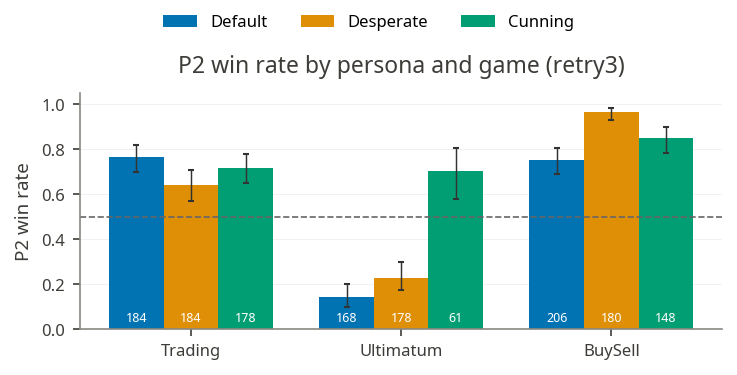

persona    default  desperate  cunning
game                                  
BuySell      0.752      0.967    0.851
Trading      0.766      0.641    0.719
Ultimatum    0.143      0.230    0.705


In [32]:
#  P2 win rate by persona and game (retry3)
t = winrate(RETRY3, ["game", "persona"])
games = list(GAMES); x = np.arange(len(games)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.4))
for i, p in enumerate(PERSONAS):
    sub = t[t["persona"] == p].set_index("game").reindex(games)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=PERSONA_LABEL[p], color=persona_pal[p])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    for xi, nv in zip(pos, sub["n"].values):       # decided-game count: the win-rate denominator
        if np.isfinite(nv):
            ax.text(xi, 0.02, f"{int(nv)}", ha="center", va="bottom", fontsize=6, color="white")
ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
ax.set_xticks(x, games); ax.set_ylabel("P2 win rate"); ax.set_ylim(0, 1.05)
ax.set_title("P2 win rate by persona and game (retry3)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "winrate_by_persona_game")
plt.show()
print(t.pivot_table(index="game", columns="persona", values="rate", observed=True)
      .reindex(columns=PERSONAS).round(3).to_string())

The persona matters most exactly where the seat is worst. 

- In **Ultimatum** the default responde wins only 0.14 of decided games (the proposer's structural advantage, the same one the cross-play benchmark found) and **cunning** lifts that to 0.71, the largest single effect in the experiment. 

- In **BuySell** the buyer already wins (0.75 at default) and **desperate** pushes it to 0.97. 

- **Trading is the exception**: neither persona helps and desperate lowers P2's win rate from 0.77 to 0.64 who reported gains in
this game for frontier models. Cunning's Ultimatum bar, though, rests on far fewer decided games than the default's (see the $n$ labels): most cunning games never reach a deal, a caveat §3 and §4 make concrete.

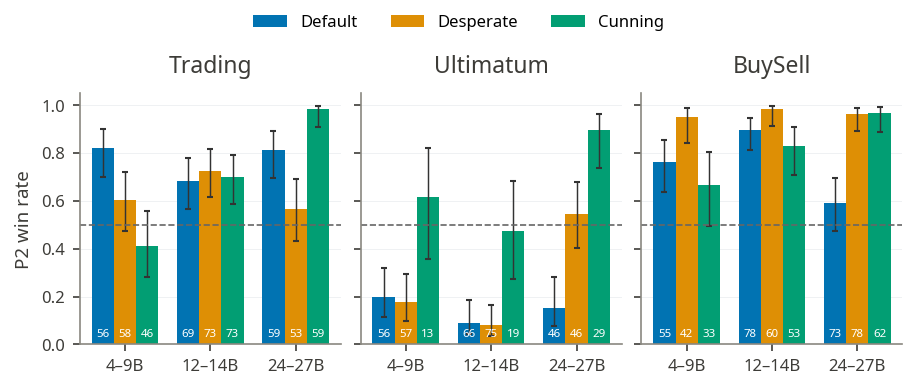

In [33]:
#  P2 win rate by persona and tier, faceted by game (retry3)
t = winrate(RETRY3, ["game", "size", "persona"])
x = np.arange(len(SIZES)); width = 0.26
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.5), sharey=True)
for ax, g in zip(axes, GAMES):
    for i, p in enumerate(PERSONAS):
        sub = (t[(t["game"] == g) & (t["persona"] == p)]
               .set_index("size").reindex(SIZES))
        pos = x + (i - 1) * width
        ax.bar(pos, sub["rate"], width, label=PERSONA_LABEL[p], color=persona_pal[p])
        ax.errorbar(pos, sub["rate"],
                    yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        for xi, nv in zip(pos, sub["n"].values):   # decided-game count per cell (small once split)
            if np.isfinite(nv):
                ax.text(xi, 0.02, f"{int(nv)}", ha="center", va="bottom", fontsize=5.5, color="white")
    ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
    ax.set_xticks(x, [SIZE_LABELS[s] for s in SIZES]); ax.set_title(g); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("P2 win rate")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "winrate_by_persona_tier")
plt.show()

Cunning's Ultimatum gain is largest at the **medium** tier (0.90) and weaker below it (0.47 at
small, 0.62 at very-small): turning a manipulative prompt into a win takes capability, and the
4–9B/12–14B responders cannot do it reliably. The per-bar samples are small once split this way
(e.g. the small-tier cunning Ultimatum cell has only 19 decided games), so the intervals are wide
and the non-monotonicity across tiers should not be over-read. Trading shows no consistent
ordering by tier for any persona.

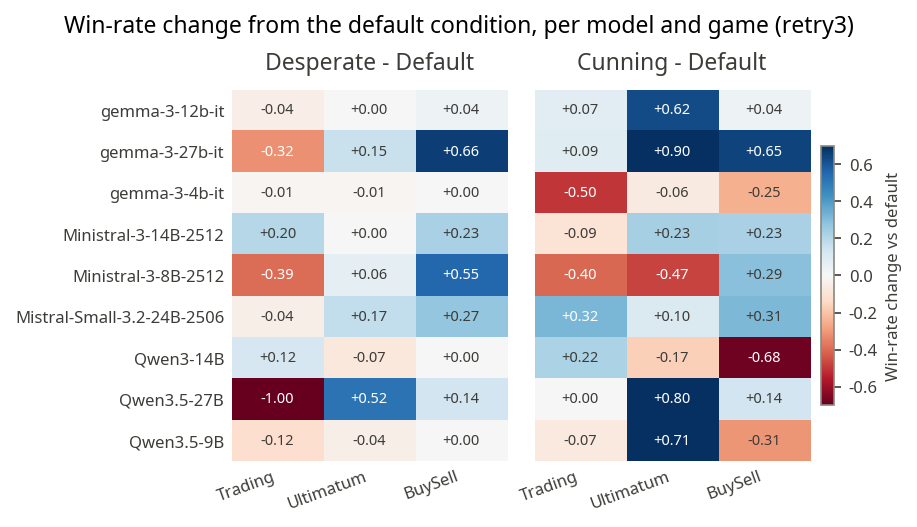

In [34]:
#  Win-rate change vs default, per model x game (retry3, pooled over tiers)
wr = winrate(RETRY3, ["game", "model", "persona"]).pivot_table(
    index=["game", "model"], columns="persona", values="rate", observed=True)
delta = wr[["desperate", "cunning"]].sub(wr["default"], axis=0)
models = sorted(RETRY3["model"].unique(),
                key=lambda m: (FAMILIES.index(model_family(m)), m))

fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.4), sharey=True)
V = 0.7
for ax, p in zip(axes, ["desperate", "cunning"]):
    mat = np.array([[delta.loc[(g, m), p] if (g, m) in delta.index else np.nan
                     for g in GAMES] for m in models], dtype=float)
    im = ax.imshow(np.ma.masked_invalid(mat), cmap="RdBu", vmin=-V, vmax=V, aspect="auto")
    ax.set_xticks(range(len(GAMES)), list(GAMES), rotation=20, ha="right")
    ax.set_yticks(range(len(models)), models)
    ax.grid(False); ax.spines[:].set_visible(False); ax.tick_params(length=0)
    ax.set_title(f"{PERSONA_LABEL[p]} - Default")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if np.isnan(mat[i, j]):
                continue
            ax.text(j, i, f"{mat[i, j]:+.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(mat[i, j]) > 0.45 * V else PHASE_TEXT)
cb = fig.colorbar(im, ax=axes, shrink=0.7, pad=0.02)
cb.set_label("Win-rate change vs default", fontsize=8)
fig.suptitle("Win-rate change from the default condition, per model and game (retry3)")
save_plot(fig, "winrate_delta_heatmap")
plt.show()

Read row by row, the persona effect is uneven and capability-dependent (blue = the persona raised
P2's win rate, red = lowered it). Cunning's Ultimatum gains are large for the capable models
(gemma-3-27b +0.90, Qwen3.5-27B +0.80, Qwen3.5-9B +0.71, gemma-3-12b +0.62) but absent or negative
for the weakest (gemma-3-4b −0.06, Ministral-8B −0.47). In Trading the cells are small and mixed in
sign, consistent with no real effect. The single largest loss is Qwen3-14B in BuySell, where
cunning collapses its buyer win rate by 0.68 — manipulation backfires when the model cannot sustain
it.

## 3. Payoff

Win rate counts decided games; it says nothing about what P2 keeps. Payoff is in native units
(Trading net resources, Ultimatum dollars, BuySell surplus) with 95% bootstrap CIs. No-deals
contribute their 0 here, so a persona that wins more often but breaks more deals can raise win rate
while lowering payoff.

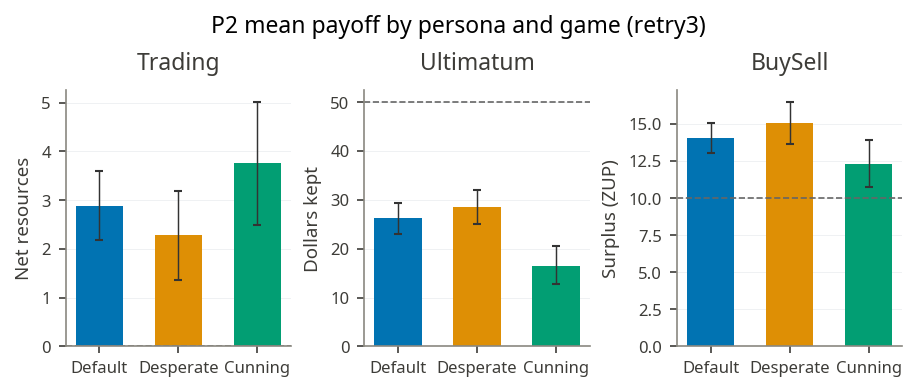

Trading {'default': 2.89, 'desperate': 2.28, 'cunning': 3.77}
Ultimatum {'default': 26.19, 'desperate': 28.54, 'cunning': 16.48}
BuySell {'default': 14.03, 'desperate': 15.06, 'cunning': 12.31}


In [35]:
#  P2 mean payoff by persona, faceted by game (retry3, native units)
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.5))
for ax, g in zip(axes, GAMES):
    t = payoff(RETRY3[RETRY3["game"] == g], ["persona"]).set_index("persona").reindex(PERSONAS)
    x = np.arange(len(PERSONAS))
    ax.bar(x, t["mean"], 0.6, color=[persona_pal[p] for p in PERSONAS])
    yerr = np.vstack([(t["mean"] - t["lo"]).clip(lower=0).values,
                      (t["hi"] - t["mean"]).clip(lower=0).values])
    ax.errorbar(x, t["mean"], yerr=yerr, fmt="none", ecolor="0.2", lw=0.7, capsize=2)
    ax.axhline(NEUTRAL[g], ls="--", lw=0.8, color="0.4")
    ax.set_xticks(x, [PERSONA_LABEL[p] for p in PERSONAS])
    ax.set_title(g); ax.set_ylabel(PAYOFF_AXIS[g])
fig.suptitle("P2 mean payoff by persona and game (retry3)")
save_plot(fig, "payoff_by_persona_game")
plt.show()
for g in GAMES:
    t = payoff(RETRY3[RETRY3["game"] == g], ["persona"]).set_index("persona").reindex(PERSONAS)
    print(g, {p: round(t.loc[p, "mean"], 2) for p in PERSONAS})

 In **Ultimatum** cunning wins the most decided games yet returns the **lowest** payoff — 16.5 dollars against the default's 26.2 — because most cunning games end in
a destroyed pot. **Desperate** instead lifts both win rate and payoff (28.5). The same split holds
in **BuySell**: desperate raises buyer surplus (15.1 vs 14.0) while cunning lowers it (12.3).
Trading payoffs are small and their intervals overlap, so no persona claim is supported there.

## No-Deals

A no-deal — a game that completes but reaches no agreement — scores 0 for both sides and is the
direct cause of the payoff paradox. We measure how often each persona ends without a deal, over
completed games.

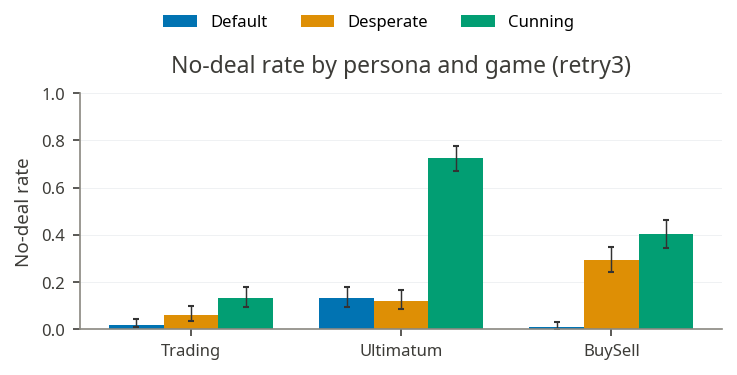

persona    default  desperate  cunning
game                                  
BuySell      0.011      0.293    0.402
Trading      0.020      0.060    0.133
Ultimatum    0.132      0.121    0.727


In [37]:
#  No-deal rate by persona and game (retry3, among completed games)
comp = RETRY3[RETRY3["completed"]]
t = rate_table(comp, "no_deal", ["game", "persona"])
games = list(GAMES); x = np.arange(len(games)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.4))
for i, p in enumerate(PERSONAS):
    sub = t[t["persona"] == p].set_index("game").reindex(games)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=PERSONA_LABEL[p], color=persona_pal[p])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.set_xticks(x, games); ax.set_ylabel("No-deal rate"); ax.set_ylim(0, 1.0)
ax.set_title("No-deal rate by persona and game (retry3)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "nodeal_by_persona_game")
plt.show()
print(t.pivot_table(index="game", columns="persona", values="rate", observed=True)
      .reindex(columns=PERSONAS).round(3).to_string())

The mechanism is unambiguous. Cunning multiplies the no-deal rate in every game, and in
**Ultimatum** it sends 0.73 of completed games to a destroyed pot (against 0.13 at default and 0.12
for desperate). This is precisely why cunning's win-rate gain in §2 does not appear as a payoff gain
in §3: it wins the games that finish, but most do not finish. Desperate, which begs rather than
insults, leaves the deal rate almost intact in Ultimatum.

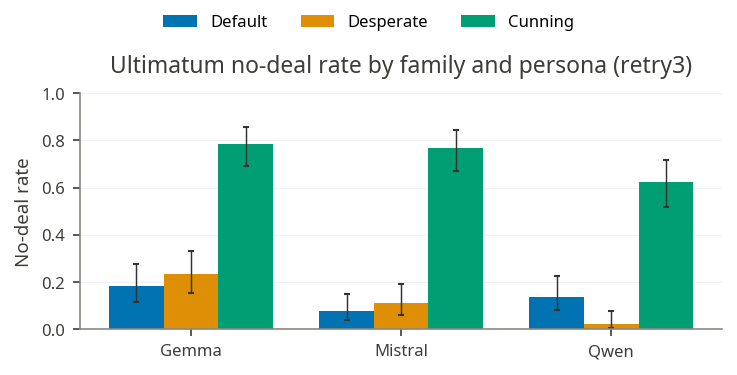

persona  default  desperate  cunning
family                              
Gemma      0.182      0.233    0.787
Mistral    0.078      0.111    0.767
Qwen       0.138      0.023    0.624


In [38]:
#  Ultimatum no-deal rate by family and persona (retry3, among completed games)
u = RETRY3[(RETRY3["game"] == "Ultimatum") & RETRY3["completed"]]
t = rate_table(u, "no_deal", ["family", "persona"])
x = np.arange(len(FAMILIES)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.4))
for i, p in enumerate(PERSONAS):
    sub = t[t["persona"] == p].set_index("family").reindex(FAMILIES)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=PERSONA_LABEL[p], color=persona_pal[p])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.set_xticks(x, FAMILIES); ax.set_ylabel("No-deal rate"); ax.set_ylim(0, 1.0)
ax.set_title("Ultimatum no-deal rate by family and persona (retry3)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "ultimatum_nodeal_family")
plt.show()
print(t.pivot_table(index="family", columns="persona", values="rate", observed=True)
      .reindex(columns=PERSONAS).round(3).to_string())

The breakdown is not one family's pathology: under cunning all three collapse the pot in most
games (Gemma 0.79, Mistral 0.77, Qwen 0.62). Qwen is the least self-destructive and is also the
family that converts cunning into the highest Ultimatum win rate in §2, which is consistent with
capability moderating how damaging the persona is — but with three families this is a suggestive
pattern, not a tested claim.